# Code set-up

In [1]:
%matplotlib inline

import os, random, time, sys, warnings
from datetime import datetime

import numpy as np
import scipy as sp
import pandas as pd
import torch
import src.utils as utils
import math
from tqdm import tqdm
from src.neural_network import ModelStateManager, ModelDataManager

# import plotting libraries
import matplotlib.pyplot as plt
plt.rcParams.update({"font.size": 8})
plt.rcParams["svg.fonttype"] = "none"
plt.rc('font', family='Arial')
import seaborn as sns
sns.set_style("white")
from src.plotting import my_reg_plot

warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

/home/ab2792/software/miniconda3/envs/neuro_rnn/lib/python3.11/site-packages/src-0.0.0-py3.11.egg/src/plotting.py:82: DeprecationWarning: invalid escape sequence '\m'


# Files set-up

In [3]:
# directories and files
username = os.getenv('USER')
if sys.platform == 'darwin':
    if username == 'ahmad':
        datadir = '/Users/ahmad/software/snaplab_github/neuro_rnn/data'
        modeldir = '/Users/ahmad/data/rutgers/neuro_rnn/results/pytorch/model'
        outdir = modeldir
elif sys.platform == 'linux':
    if username == 'ab2792':
        datadir = '/home/ab2792/software/snaplab_github/neuro_rnn/data'
        modeldir = '/home/ab2792/data/neuro_rnn/results/pytorch/model/20241114'
        outdir = modeldir
    elif username == 'lindenmp':
        datadir = '/home/lindenmp/research_projects/neuro_rnn/data'
        modeldir = '/media/lindenmp/storage_ssd/research_projects/neuro_rnn/results/model_cpu'
        outdir = '/home/lindenmp/research_projects/neuro_rnn/results/figs'

check_only = False
verbose = True
save_figs = True

# are we plotting results for all tasks?
rows_to_plot = []
# rows_to_plot = [103]
# rows_to_plot = list(np.arange(36,54)) 
# rows_to_plot = list(np.concatenate((np.arange(30),np.arange(45,60)))) 

# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_a_rescale.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_b_rescale_adj.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_c_mean_002.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_d_mean_001.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_e_mean_005.csv')
# model_params_file = os.path.join(datadir, 'model_params_gng_5x5_mean_002_500runs.csv')
# model_params_file = os.path.join(datadir, 'model_params_pdm_3x6_mean_002_100runs.csv')
# model_params_file = os.path.join(datadir, 'test_models.csv')
model_params_file = os.path.join(datadir, 'model_params_gng_pdm_100runs.csv')

model_params, task_names, n_tasks, kernel_labels, n_kernels = utils.get_params_dataframe(model_params_file, rows=rows_to_plot, verbose=verbose)
n_models = len(model_params)
# if verbose:
model_params


Tasks:
------
GoNogo-v0-Del_900_200
PerceptualDecisionMaking-v0-Del_200_0_Dec_400
MultiSensoryIntegration-v0-Dec_400
 
Kernel types:
-------------
Masked S-A
Masked Eucl.
Masked Reg. 
 
DataFrame keys:
---------------
task
seq_len_multi
rnn_model
hidden_size
batch_size
learning_rate
n_runs
n_epochs
mask_weights
reg_type
reg_weight
kernel_type
kernel_normalization
time_step
kernel_label
task_label
task_index
kernel_index
task_no_modifier
task_modifier
task_with_modifier
n_io
seq_len
config
file_str_models
file_str_outputs
env_kwargs
model_index
 


,task,seq_len_multi,rnn_model,hidden_size,batch_size,learning_rate,n_runs,n_epochs,mask_weights,reg_type,...,task_no_modifier,task_modifier,task_with_modifier,n_io,seq_len,config,file_str_models,file_str_outputs,env_kwargs,model_index
0,GoNogo-v0-Del_900_200,5,rnn-tanh,100,32,0.001,100,5000,True,l2,...,GoNogo-v0,Del_900_200,GoNogo-v0-Del_900_200,14-27,100,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-GoNogo-v0-Del_900_200-100_model-rnn-tanh-...,task-GoNogo-v0-Del_900_200-100_model-rnn-tanh-...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",0
1,GoNogo-v0-Del_900_200,5,rnn-tanh,100,32,0.001,100,5000,True,l2,...,GoNogo-v0,Del_900_200,GoNogo-v0-Del_900_200,14-27,100,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-GoNogo-v0-Del_900_200-100_model-rnn-tanh-...,task-GoNogo-v0-Del_900_200-100_model-rnn-tanh-...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",1
2,GoNogo-v0-Del_900_200,5,rnn-tanh,100,32,0.001,100,5000,True,l2,...,GoNogo-v0,Del_900_200,GoNogo-v0-Del_900_200,14-27,100,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-GoNogo-v0-Del_900_200-100_model-rnn-tanh-...,task-GoNogo-v0-Del_900_200-100_model-rnn-tanh-...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",2
3,PerceptualDecisionMaking-v0-Del_200_0_Dec_400,5,rnn-tanh,100,32,0.001,100,25000,True,l2,...,PerceptualDecisionMaking-v0,Del_200_0_Dec_400,PerceptualDecisionMaking-v0-Del_200_0_Dec_400,14-27,95,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-PerceptualDecisionMaking-v0-Del_200_0_Dec...,task-PerceptualDecisionMaking-v0-Del_200_0_Dec...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",3
4,PerceptualDecisionMaking-v0-Del_200_0_Dec_400,5,rnn-tanh,100,32,0.001,100,25000,True,l2,...,PerceptualDecisionMaking-v0,Del_200_0_Dec_400,PerceptualDecisionMaking-v0-Del_200_0_Dec_400,14-27,95,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-PerceptualDecisionMaking-v0-Del_200_0_Dec...,task-PerceptualDecisionMaking-v0-Del_200_0_Dec...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",4
5,PerceptualDecisionMaking-v0-Del_200_0_Dec_400,5,rnn-tanh,100,32,0.001,100,25000,True,l2,...,PerceptualDecisionMaking-v0,Del_200_0_Dec_400,PerceptualDecisionMaking-v0-Del_200_0_Dec_400,14-27,95,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-PerceptualDecisionMaking-v0-Del_200_0_Dec...,task-PerceptualDecisionMaking-v0-Del_200_0_Dec...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",5
6,MultiSensoryIntegration-v0-Dec_400,5,rnn-tanh,100,32,0.001,100,25000,True,l2,...,MultiSensoryIntegration-v0,Dec_400,MultiSensoryIntegration-v0-Dec_400,14-27,75,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-MultiSensoryIntegration-v0-Dec_400-75_mod...,task-MultiSensoryIntegration-v0-Dec_400-75_mod...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",6
7,MultiSensoryIntegration-v0-Dec_400,5,rnn-tanh,100,32,0.001,100,25000,True,l2,...,MultiSensoryIntegration-v0,Dec_400,MultiSensoryIntegration-v0-Dec_400,14-27,75,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-MultiSensoryIntegration-v0-Dec_400-75_mod...,task-MultiSensoryIntegration-v0-Dec_400-75_mod...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",7
8,MultiSensoryIntegration-v0-Dec_400,5,rnn-tanh,100,32,0.001,100,25000,True,l2,...,MultiSensoryIntegration-v0,Dec_400,MultiSensoryIntegration-v0-Dec_400,14-27,75,"{'dt': 100, 'batch_size': 32, 'rnn_model': 'rn...",task-MultiSensoryIntegration-v0-Dec_400-75_mod...,task-MultiSensoryIntegration-v0-Dec_400-75_mod...,"{'dt': 100, 'timing': {'fixation': 300, 'stimu...",8


# Load data

In [5]:
if check_only:
    
    found_count = 0
    for model_idx in range(n_models):
        this = model_params.iloc[model_idx]
        file_path = os.path.join(modeldir, this.file_str_outputs)
        file_exists = os.path.isfile(file_path)
        if file_exists:
            found_count += 1
        else:
            print(f'Not found ... {this.file_str_outputs} ({model_idx})')
    print(f'Found {found_count}/{n_models} files.')
    
else:
    
    loaded_data = []
    
    for model_idx in tqdm(np.arange(n_models), desc='Loading data'):
        
        # get model details
        this = model_params.iloc[model_idx]
        utils.check_if_supported(task=this.task_no_modifier, modifier=this.task_modifier)

        # get data file name
        file_path = os.path.join(modeldir, this.file_str_outputs)

        try:
            # load data
            output_manager = ModelDataManager(file_path)
            test_accuracy_all_runs = output_manager.load_key_across_runs('test_accuracy')
            loaded_data.append(test_accuracy_all_runs)
        except:
            print("An error occurred:", sys.exc_info()[0])
            print("Exception message:", sys.exc_info()[1])

Loading data: 100%|███████████████████████████████| 9/9 [00:28<00:00,  3.20s/it]


# Model performance

/home/ab2792/software/miniconda3/envs/neuro_rnn/lib/python3.11/site-packages/IPython/core/pylabtools.py:77: DeprecationWarning: backend2gui is deprecated since IPython 8.24, backends are managed in matplotlib and can be externally registered.
  warnings.warn(
Plotting: 100%|███████████████████████████████████| 9/9 [00:00<00:00, 14.38it/s]


ValueError: x and y must have same first dimension, but have shapes (250,) and (50,)

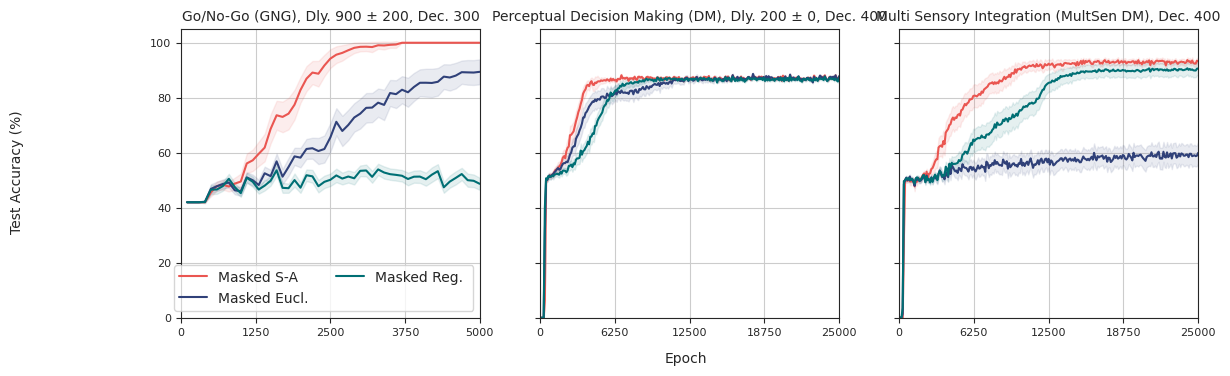

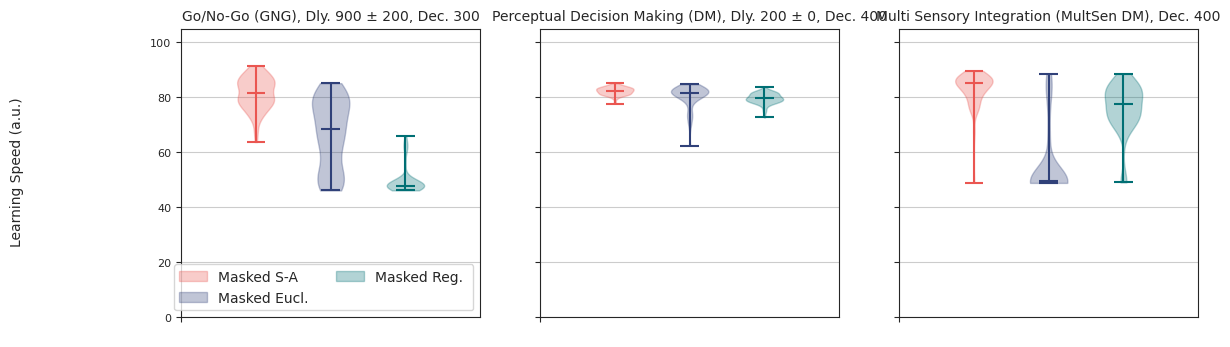

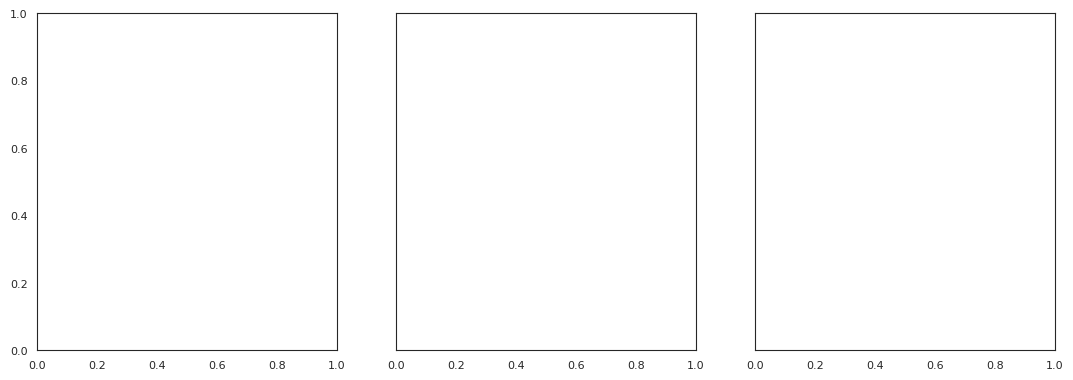

In [6]:
if not check_only:
    
    # import colors
    color_palette = utils.get_my_colors(cat_trio=False, as_list=True)

    # initialise figures
    size_scale = 1.25
    font_size = int(8 * size_scale)
    n_fig_columns = min((6, n_tasks))
    n_fig_rows = math.ceil( n_tasks / n_fig_columns )
    fig_size_w = 3.5*n_fig_columns*size_scale
    fig_size_h = 3*n_fig_rows*size_scale
    f_plots, ax_plots = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                         squeeze=True, sharex=False, sharey=True)
    f_violin, ax_violin = plt.subplots(n_fig_rows, n_fig_columns, figsize=(fig_size_w,fig_size_h),
                         squeeze=True, sharex=False, sharey=True)
    comparison_kernels = ['Masked Eucl.', 'Masked Reg. ', 'Masked Unreg. ']
    f_diff, ax_diff = plt.subplots(1, len(comparison_kernels), figsize=(3.5*size_scale*len(comparison_kernels),3.5*size_scale),
                                   squeeze=True, sharex=False, sharey=True)
    plt.rcParams['font.size'] = font_size
    xlims_plots = np.zeros(n_tasks)
    violin_bodies = []
    all_means = [{} for _ in range(n_tasks)]

    for model_idx in tqdm(np.arange(n_models), desc='Plotting'):
        
        # get model details
        this = model_params.iloc[model_idx]
        n_runs = this.n_runs
        n_runs = 85
        
        try:
            
            # get data
            test_accuracy_all_runs = loaded_data[model_idx]
            
            # extract accuracy from each run
            test_accuracy = np.zeros((n_runs,test_accuracy_all_runs[0].shape[0]-1))
            for run in np.arange(n_runs):
                test_accuracy[run,:] = test_accuracy_all_runs[run][1:] * 100

            n_epochs_actual = test_accuracy.shape[1] * 100
            n_logged_epochs = int(n_epochs_actual / 100)
            x_step = int(n_epochs_actual / (n_logged_epochs))
            x = np.arange(x_step, n_epochs_actual + x_step, x_step)

            # compute mean and ci across runs
            accuracy_mean_runs = test_accuracy.mean(axis=0)
            accuracy_std_runs = test_accuracy.std(axis=0)
            ci = 1.96 * (accuracy_std_runs / np.sqrt(test_accuracy.shape[0]))
            ci_lower = accuracy_mean_runs - ci
            ci_upper = accuracy_mean_runs + ci
            
            # compute mean of each run across time
            accuracy_mean_epochs = test_accuracy.mean(axis=1)
            
            # add values to sa_vs_euc list
            all_means[this.task_index][this.kernel_index] = accuracy_mean_runs

            # plot mean accuracy vs. time
            f_plots.axes[this.task_index].plot(x, accuracy_mean_runs, color=color_palette[this.kernel_index], label=str(this.kernel_label))
            f_plots.axes[this.task_index].fill_between(x, ci_lower, ci_upper, color=color_palette[this.kernel_index], alpha=0.1)
            xlims_plots[this.task_index] = np.max((xlims_plots[this.task_index],n_epochs_actual))
            
            # plot time-averaged accuracy as violin plot
            violin_parts = f_violin.axes[this.task_index].violinplot(dataset=accuracy_mean_epochs, positions=[this.kernel_index], showmedians=True)
            for partname in ('cbars','cmins','cmaxes','cmedians'):
                vp = violin_parts[partname]
                vp.set_edgecolor(color_palette[this.kernel_index])
            for pc in violin_parts['bodies']:
                pc.set_facecolor(color_palette[this.kernel_index])
                pc.set_edgecolor(color_palette[this.kernel_index])
            if this.task_index == 0:
                violin_bodies.append(violin_parts['bodies'][0])

            # inset axis
            # if task_index == 1:
            #     x1, x2, y1, y2 = 3000, 17500, 70, 95
            #     axins = f.axes[task_index].inset_axes([0.4, 0, 0.6, 0.55], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
            #     axins.plot(x[int(x1/100)-1:int(x2/100)-1], accuracy_mean_runs[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index])
            #     axins.fill_between(x[int(x1/100)-1:int(x2/100)-1], ci_lower[int(x1/100)-1:int(x2/100)-1], ci_upper[int(x1/100)-1:int(x2/100)-1], color=color_palette[kernel_index], alpha=0.1)
            #     axins.patch.set_alpha(0)
            #     f.axes[task_index].indicate_inset_zoom(axins, edgecolor="black")
            
        except:
            
            print("An error occurred:", sys.exc_info()[0])
            print("Exception message:", sys.exc_info()[1])

    # set title and labels for line plots
    xlim_method = 'auto' # 'auto' or x
    legend_ncol=2
    for task_index in np.arange(n_tasks):
        # f.axes[task_index].set_xlabel('Epochs', fontsize=font_size)
        # if task_index == 0: f.axes[task_index].set_ylabel('Test Accuracy (%)', fontsize=font_size)
        if xlim_method == 'auto':
            xmax = xlims_plots[task_index]
        else:
            xmax = xlim_method
        f_plots.axes[task_index].set_xlim([0, xmax+10])
        f_plots.axes[task_index].set_ylim([0, 105])
        f_plots.axes[task_index].set_xticks(np.arange(0,xmax+10,int(xmax/4)))
        f_plots.axes[task_index].set_yticks(np.arange(0,100+1,20))
        f_plots.axes[task_index].tick_params(bottom=True,left=True)
        if task_index == 0:
            f_plots.axes[task_index].legend(loc='lower right',ncol=legend_ncol)
        f_plots.axes[task_index].set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)
        f_plots.axes[task_index].grid()
    f_plots.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    f_plots.text(0.0, 0.5, 'Test Accuracy (%)', ha='center', va='center', rotation='vertical')
    
    # set title and labels for violin plots
    for task_index in np.arange(n_tasks):
        f_violin.axes[task_index].set_ylim([0, 105])
        x_ticks = np.arange(0,n_kernels+1)
        f_violin.axes[task_index].set_xticks(x_ticks)
        f_violin.axes[task_index].set_xticks((-1,))
        f_violin.axes[task_index].set_xticklabels([' '])
        f_violin.axes[task_index].set_yticks(np.arange(0,100+1,20))
        f_violin.axes[task_index].tick_params(bottom=True,left=True)
        if task_index == 0:
            f_violin.axes[task_index].legend(violin_bodies, kernel_labels, loc='lower right',ncol=legend_ncol)
        f_violin.axes[task_index].set_title(utils.get_task_label(task_names[task_index]), fontsize=font_size)
        f_violin.axes[task_index].grid()
    # f_violin.text(0.0, 0.5, ' ', ha='center', va='center', rotation='vertical')
    f_violin.text(0.0, 0.5, 'Learning Speed (a.u.)', ha='center', va='center', rotation='vertical')
    
    # plot sa vs. eucl means
    y_min = 0
    y_max = 0
    for idx in range(len(comparison_kernels)):
        diff_vals = np.zeros((n_tasks,all_means[0][0].shape[0]))
        idx_a = kernel_labels.index('Masked S-A')
        idx_b = kernel_labels.index(comparison_kernels[idx])
        for task_index in range(n_tasks):
            y = all_means[task_index][idx_a] - all_means[task_index][idx_b]
            y_min = min(y_min, min(y))
            y_max = max(y_max, max(y))
            f_diff.axes[idx].plot(x, y, linestyle='-', linewidth=1., color=[0,0,0], alpha=0.1)
            diff_vals[task_index,:] = y
        f_diff.axes[idx].plot(x, np.mean(diff_vals,axis=0), linestyle='-', linewidth=2.5, color=color_palette[idx_b], alpha=1.)
        y_lim = 1.1*(max(np.abs(y_min),np.abs(y_max)))
        f_diff.axes[idx]
        # f_diff.axes[idx].set_ylim([-y_lim,y_lim])
        f_diff.axes[idx].set_xlim([0,xmax])
        f_diff.axes[idx].tick_params(bottom=True,left=True)
        f_diff.axes[idx].set_xticks(np.arange(0,xmax+10,int(xmax/4)))
        f_diff.axes[idx].set_title('Masked S-A vs. ' + comparison_kernels[idx], fontsize=font_size)
        f_diff.axes[idx].grid()
    f_diff.text(0.51, 0.0, 'Epoch', ha='center', va='center')
    f_diff.text(0.0, 0.5, 'Accuracy difference (%)', ha='center', va='center', rotation='vertical')

    
    sns.despine(fig=f_plots, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    sns.despine(fig=f_violin, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    sns.despine(fig=f_diff, offset=0, trim=False, left=False, right=True, top=True, bottom=False)
    
    f_plots.tight_layout()
    f_violin.tight_layout()
    f_diff.tight_layout()
    plt.show()
    
    # save svg
    if save_figs:
        models_file = os.path.splitext(os.path.basename(model_params_file))[0]
        file_str_plots = 'accuracy_{:}_plots.svg'.format(models_file)
        file_str_violin = 'accuracy_{:}_violin.svg'.format(models_file)
        file_str_diff = 'accuracy_{:}_diff.svg'.format(models_file)
        f_plots.savefig(os.path.join(outdir, file_str_plots), dpi=300, bbox_inches='tight', pad_inches=0.01)
        f_violin.savefig(os.path.join(outdir, file_str_violin), dpi=300, bbox_inches='tight', pad_inches=0.01)
        f_diff.savefig(os.path.join(outdir, file_str_diff), dpi=300, bbox_inches='tight', pad_inches=0.01)